In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import tensorflow as tf
# Ganti tf.contrib.learn dengan Keras layers
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])
model.compile(optimizer='sgd', loss='mean_squared_error')

import os
import tensorflow as tf

# Cara ni akan sorokkan semua warning kecuali Error
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# Kalau nak guna gaya Python standard:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

c:\Users\AHMAD ADAM HAKIMI\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# mnist = tf.keras.datasets.mnist
# (training_images, training_labels), (test_images, test_labels) = mnist.load_data()

# training_images = training_images / 255.0
# test_images = test_images / 255.0

# # 3. Bina Model yang lebih "Smart"
# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape=(28, 28)), # Tukar gambar 2D jadi 1D
#     tf.keras.layers.Dense(128, activation='relu'), # "Otak" tengah
#     tf.keras.layers.Dense(10, activation='softmax') # Output untuk 10 nombor (0-9)
# ])

# model.compile(optimizer='adam', 
#               loss='sparse_categorical_crossentropy', 
#               metrics=['accuracy'])

# # 4. Train
# model.fit(training_images, training_labels, epochs=5)

In [15]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

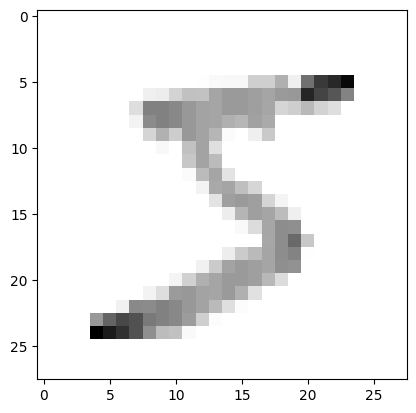

In [16]:
def draw(n):
    plt.imshow(n, cmap=plt.cm.binary)
    plt.show()

draw(x_train[0])

In [17]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))

model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

model.fit(x_train,y_train, epochs=3)


c:\Users\AHMAD ADAM HAKIMI\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9248 - loss: 0.2590
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9673 - loss: 0.1063
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9777 - loss: 0.0706


In [18]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print("loss-> ", val_loss, "\nacc->", val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - loss: 0.1013
loss->  0.10129047185182571 
acc-> 0.968500018119812


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label ->  4
prediction ->  4


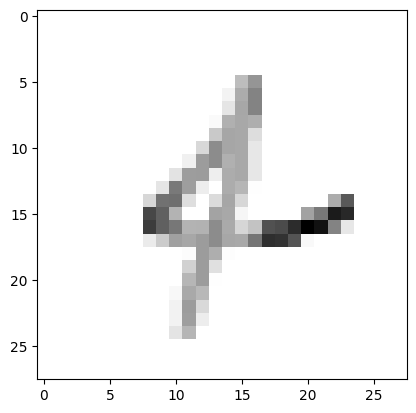

In [32]:
predictions=model.predict([x_test])
n = 300
print('label -> ', y_test[n])
print('prediction -> ', np.argmax(predictions[n]))

draw(x_test[n])

In [39]:
model.save('epic_num_reader.h5')

In [38]:
# Guna custom_objects untuk "translate" nama fungsi lama ke baru
import tensorflow as tf

try:
    new_model = tf.keras.models.load_model('epic_num_reader.h5', 
                 custom_objects={'softmax_v2': tf.nn.softmax})
    print("Berjaya load!")
except Exception as e:
    print(f"Masih gagal sebab: {e}")

Berjaya load!


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
label ->  5
prediction ->  5


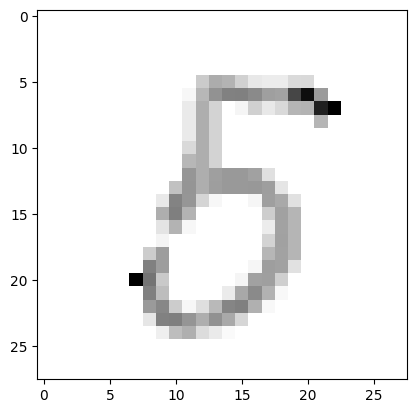

In [41]:
predictions=new_model.predict([x_test])
n=45
print('label -> ', y_test[n])
print('prediction -> ', np.argmax(predictions[n]))

draw(x_test[n])